In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.TimeSeriesAnalysis import select_random_json, create_folder, read_experiment_json, compute_means_for_folder_tests
from src.analysis_L_min_functions import calculate_means_L, generate_pc_estimate, detect_equilibrium_start_with_errors, weighted_mean_and_sem, idx_from_t0, read_mean_json
plt.style.use('properties.mplstyle')
import os

In [41]:
results_folder = "../results/TimeSeries/3D/define_pt/"
create_folder(results_folder)

## COMPUTE MEANS FOR FOLDERS

In [13]:
DIM = 3
N_COLORS = 4
NT = 3000
K = 1.0e-6
RHO = 1/N_COLORS
p0 = [1.0]

L_lst = calculate_means_L(N_COLORS, DIM, NT, K, RHO, p0)
generate_pc_estimate(L_lst, N_COLORS, DIM, NT, K, RHO)

[ok] p0=1.00: 90 arquivos | seeds=90 | pc_SOP=0.960150±0.000359
[salvo] ../Data_tests/bond_percolation/num_colors_4/dim_3/L_128/NT_constant/NT_3000/k_1.0e-06/rho_2.5000e-01/properties_mean_bundle.json
[ok] p0=1.00: 40 arquivos | seeds=40 | pc_SOP=0.262764±0.000410
[salvo] ../Data_tests/bond_percolation/num_colors_4/dim_3/L_512/NT_constant/NT_3000/k_1.0e-06/rho_2.5000e-01/properties_mean_bundle.json
[ok] p0=1.00: 90 arquivos | seeds=90 | pc_SOP=0.340688±0.001401
[salvo] ../Data_tests/bond_percolation/num_colors_4/dim_3/L_256/NT_constant/NT_3000/k_1.0e-06/rho_2.5000e-01/properties_mean_bundle.json
[ok] p0=1.00: 10 arquivos | seeds=10 | pc_SOP=0.251933±0.000017
[salvo] ../Data_tests/bond_percolation/num_colors_4/dim_3/L_1024/NT_constant/NT_3000/k_1.0e-06/rho_2.5000e-01/properties_mean_bundle.json


In [23]:
fn = "../Data_tests/bond_percolation/pc_estimative.csv"
df = pd.read_csv(fn, sep=',')
df

,L,nc,dim,NT,k,rho,t0,pc,pc_err,err_rel,order,N_samples
0,260,1,3,3000,0.000001,1.0,515.0,0.252203,0.000019,1.362908,1,40
1,265,1,3,3000,0.000001,1.0,455.0,0.251912,0.000017,1.245950,1,40
2,270,1,3,3000,0.000001,1.0,342.0,0.251804,0.000015,1.202403,1,40
3,275,1,3,3000,0.000001,1.0,372.0,0.251688,0.000014,1.155875,1,40
4,280,1,3,3000,0.000001,1.0,327.0,0.251545,0.000014,1.098667,1,40
5,285,1,3,3000,0.000001,1.0,370.0,0.251359,0.000010,1.023936,1,80
6,286,1,3,3000,0.000001,1.0,383.0,0.251417,0.000014,1.046875,1,40
7,287,1,3,3000,0.000001,1.0,470.0,0.251365,0.000007,1.025984,1,200
8,288,1,3,3000,0.000001,1.0,590.0,0.251326,0.000008,1.010379,1,200
9,289,1,3,3000,0.000001,1.0,366.0,0.251292,0.000014,0.996690,1,40


## MULTI SAMPLE

N_samples (num_seeds) = 90
t0 individual: 241.00, 245.00, 273.00, 267.00
t0 GLOBAL (usado para todas): 273.00
[serie 1] mean_eq=0.26871258 ± 0.00001882 | err_rel=7.998%
[serie 2] mean_eq=0.26907349 ± 0.00001878 | err_rel=8.143%
[serie 3] mean_eq=0.26900002 ± 0.00001827 | err_rel=8.114%
[serie 4] mean_eq=0.26926495 ± 0.00001866 | err_rel=8.220%


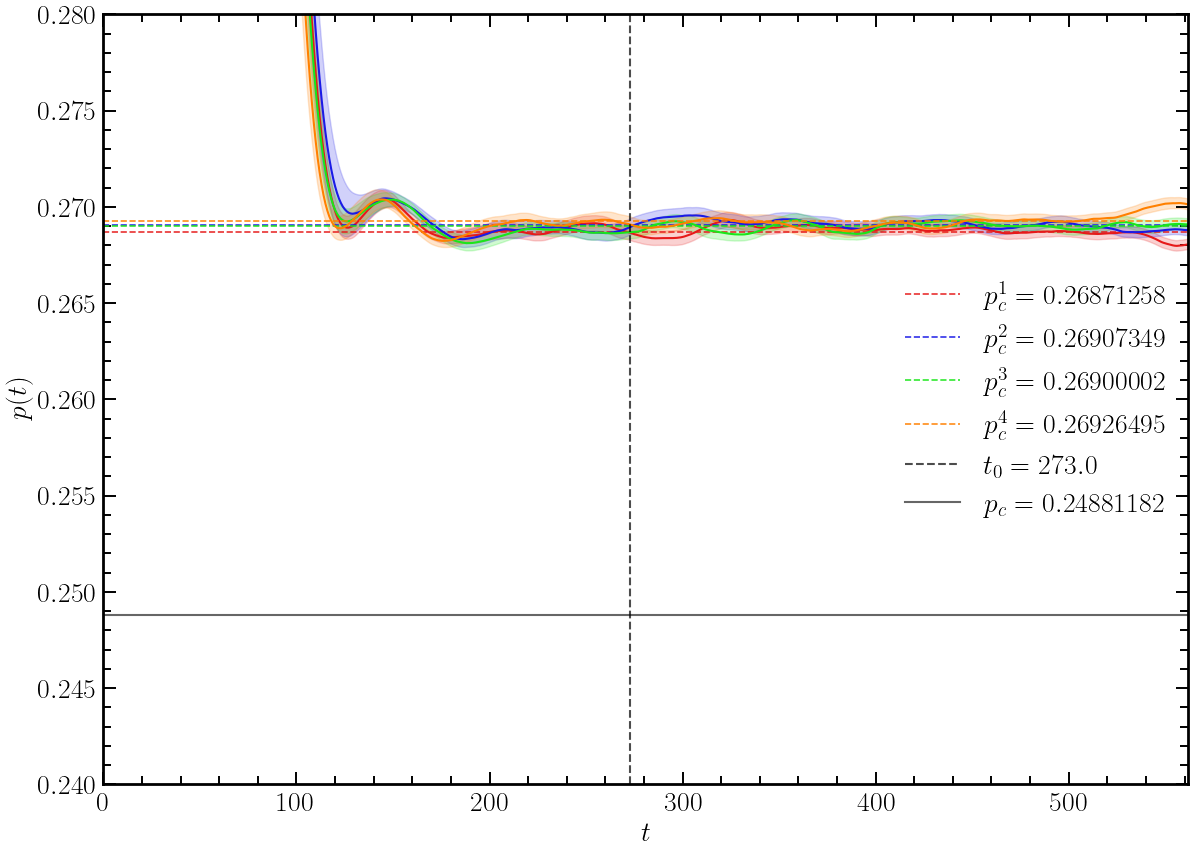

In [18]:
import numpy as np
import matplotlib.pyplot as plt

DIM = 3
N_COLORS = 4
L = 256
NT = 3000
K = 1.0e-6
RHO = 1 / N_COLORS

orders, num_seeds = read_mean_json(N_COLORS, DIM, L, NT, K, RHO)
print("N_samples (num_seeds) =", num_seeds)

# se por algum motivo ainda vier dict {"0":..., "1":...}, normaliza aqui
if isinstance(orders, dict):
    if "0" in orders:
        orders = [orders[str(i)] for i in range(N_COLORS)]
    else:
        orders = [orders[i] for i in range(N_COLORS)]

colors_used = [
    (0.9, 0.1, 0.1),
    (0.1, 0.1, 0.9),
    (0.1, 0.9, 0.1),
    (1.0, 0.5, 0.0),
    (0.8, 0.2, 0.8),
    (0.2, 0.8, 0.8),
    (1.0, 1.0, 0.0),
    (0.6, 0.4, 0.2),
]

pc = 0.24881182

# lê as séries
series = []
for i in range(N_COLORS):
    d = orders[i]["data"]
    t = np.array(d["time"], dtype=float)
    pt = np.array(d["pt_mean"], dtype=float)
    pt_sem = np.array(d["pt_sem"], dtype=float)
    series.append((t, pt, pt_sem))

# estima t0 individual e t0 global
t0_ind = []
for (t, pt, pt_sem) in series:
    idx0_i = detect_equilibrium_start_with_errors(
        t, pt, pt_sem, w=40, consec=6, z=2.0, chi2r_max=2.0
    )
    t0_ind.append(float(t[idx0_i]))

t0_global = float(max(t0_ind))

# print robusto (serve p/ N_COLORS=1 também)
print("t0 individual:", ", ".join([f"{x:.2f}" for x in t0_ind]))
print(f"t0 GLOBAL (usado para todas): {t0_global:.2f}")

# plot
plt.figure()

for i, (t, pt, pt_sem) in enumerate(series):
    idx0_g = idx_from_t0(t, t0_global)

    mean_eq, sem_eq = weighted_mean_and_sem(pt[idx0_g:], pt_sem[idx0_g:])
    err = (abs(mean_eq - pc) / pc) * 100

    print(f"[serie {i+1}] mean_eq={mean_eq:.8f} ± {sem_eq:.8f} | err_rel={err:.3f}%")

    plt.plot(t, pt, ls='-', color=colors_used[i])
    plt.fill_between(t, pt - pt_sem, pt + pt_sem, alpha=0.20, color=colors_used[i])

    plt.axhline(
        mean_eq, linestyle="--", linewidth=1.2,
        label=rf"$p_c^{i+1}={mean_eq:.8f}$",
        alpha=0.9, color=colors_used[i]
    )

# marca t0 global
plt.axvline(t0_global, linestyle="--", linewidth=1.5, color="k", alpha=0.7, label=f"$t_0 = {t0_global}$")

# referência pc
plt.axhline(y=pc, linestyle="-", color="k", label=rf"$p_c={pc:.8f}$", alpha=0.6)

plt.xlabel(r"$t$")
plt.ylabel(r"$p(t)$")
plt.xlim(0, max(series[0][0]))
plt.ylim(0.24, 0.28)
plt.legend()
plt.show()



=== L=256 ===
N_samples (num_seeds) = 90
t0 individual: 241.00, 245.00, 273.00, 267.00
t0 GLOBAL (usado para todas): 273.00
[serie 1] mean_eq=0.26871258 ± 0.00001882 | err_rel=7.998%
[serie 2] mean_eq=0.26907349 ± 0.00001878 | err_rel=8.143%
[serie 3] mean_eq=0.26900002 ± 0.00001827 | err_rel=8.114%
[serie 4] mean_eq=0.26926495 ± 0.00001866 | err_rel=8.220%

=== L=512 ===
N_samples (num_seeds) = 40
t0 individual: 477.00, 412.00, 425.00, 445.00
t0 GLOBAL (usado para todas): 477.00
[serie 1] mean_eq=0.25206278 ± 0.00000896 | err_rel=1.307%
[serie 2] mean_eq=0.25208648 ± 0.00000891 | err_rel=1.316%
[serie 3] mean_eq=0.25213050 ± 0.00000891 | err_rel=1.334%
[serie 4] mean_eq=0.25212575 ± 0.00000889 | err_rel=1.332%

=== L=1024 ===
N_samples (num_seeds) = 10
t0 individual: 509.00, 518.00, 538.00, 490.00
t0 GLOBAL (usado para todas): 538.00
[serie 1] mean_eq=0.24938430 ± 0.00000693 | err_rel=0.230%
[serie 2] mean_eq=0.24951989 ± 0.00000709 | err_rel=0.285%
[serie 3] mean_eq=0.24952040 ± 0.0

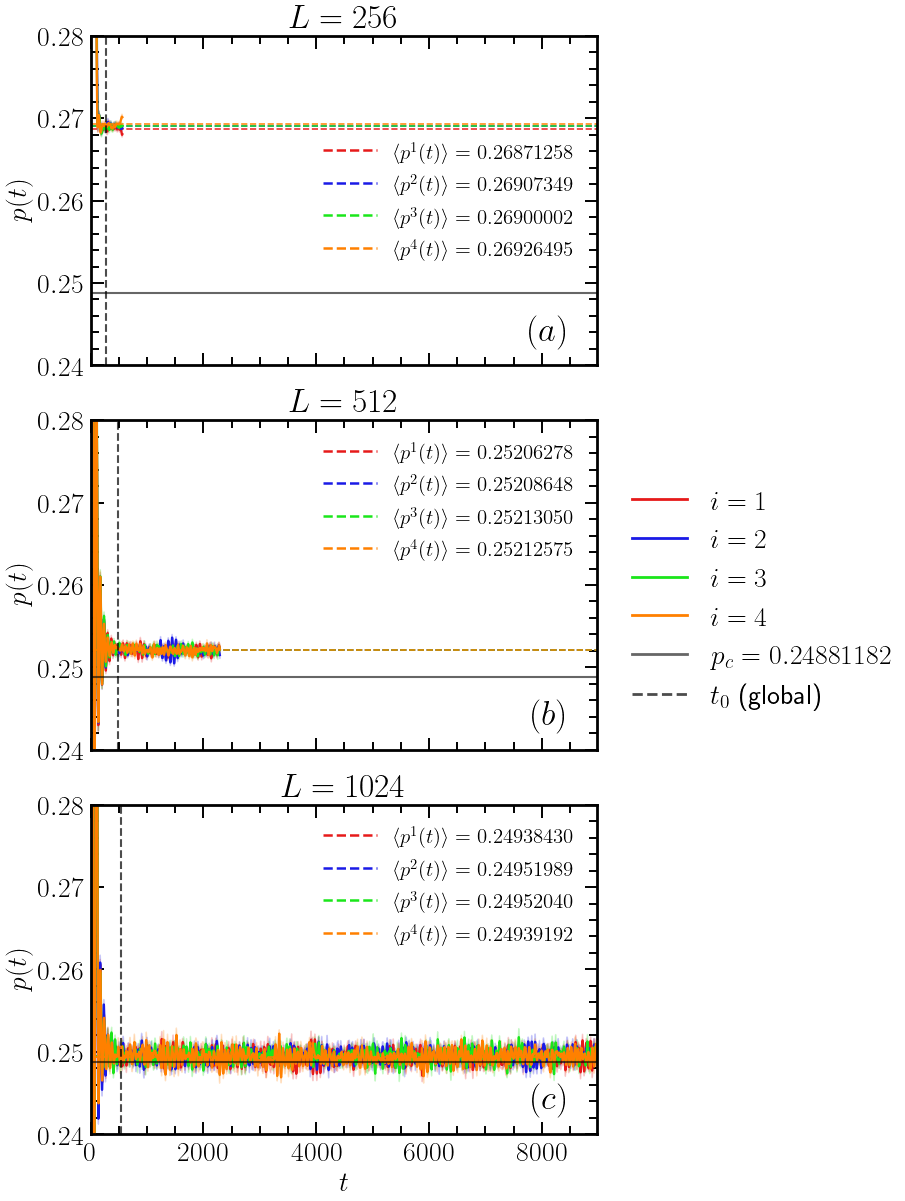

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

DIM = 3
N_COLORS = 4
NT = 3000
K = 1.0e-6
RHO = 1 / N_COLORS

L_lst = [256, 512, 1024]

colors_used = [
    (0.9, 0.1, 0.1),
    (0.1, 0.1, 0.9),
    (0.1, 0.9, 0.1),
    (1.0, 0.5, 0.0),
    (0.8, 0.2, 0.8),
    (0.2, 0.8, 0.8),
    (1.0, 1.0, 0.0),
    (0.6, 0.4, 0.2),
]

pc = 0.24881182

fig, axes = plt.subplots(
    3, 1, figsize=(6, 12),
    sharey=True,
    sharex=True,
    constrained_layout=True
)

axes = np.atleast_1d(axes)
labels_alfa = ['$(a)$', '$(b)$', '$(c)$']
for idx_ax, (ax, L) in enumerate(zip(axes, L_lst)):

    orders, num_seeds = read_mean_json(N_COLORS, DIM, L, NT, K, RHO)
    print(f"\n=== L={L} ===")
    print("N_samples (num_seeds) =", num_seeds)

    if isinstance(orders, dict):
        if "0" in orders:
            orders = [orders[str(i)] for i in range(N_COLORS)]
        else:
            orders = [orders[i] for i in range(N_COLORS)]

    series = []
    for i in range(N_COLORS):
        d = orders[i]["data"]
        t = np.array(d["time"], dtype=float)
        pt = np.array(d["pt_mean"], dtype=float)
        pt_sem = np.array(d["pt_sem"], dtype=float)
        series.append((t, pt, pt_sem))

    t0_ind = []
    for (t, pt, pt_sem) in series:
        idx0_i = detect_equilibrium_start_with_errors(
            t, pt, pt_sem, w=40, consec=6, z=2.0, chi2r_max=2.0
        )
        t0_ind.append(float(t[idx0_i]))
    t0_global = float(max(t0_ind))

    print("t0 individual:", ", ".join([f"{x:.2f}" for x in t0_ind]))
    print(f"t0 GLOBAL (usado para todas): {t0_global:.2f}")

    mean_eq_list = []

    for i, (t, pt, pt_sem) in enumerate(series):
        idx0_g = idx_from_t0(t, t0_global)
        mean_eq, sem_eq = weighted_mean_and_sem(pt[idx0_g:], pt_sem[idx0_g:])
        mean_eq_list.append(mean_eq)

        err = (abs(mean_eq - pc) / pc) * 100
        print(f"[serie {i+1}] mean_eq={mean_eq:.8f} ± {sem_eq:.8f} | err_rel={err:.3f}%")

        ax.plot(t, pt, ls='-', color=colors_used[i], lw=1.6)
        ax.fill_between(t, pt - pt_sem, pt + pt_sem, alpha=0.20, color=colors_used[i])
        ax.axhline(mean_eq, linestyle="--", linewidth=1.2, alpha=0.9, color=colors_used[i])

    ax.axvline(t0_global, linestyle="--", linewidth=1.5, color="k", alpha=0.7)
    ax.axhline(y=pc, linestyle="-", color="k", alpha=0.6)

    ax.set_title(fr"$L={L}$")
    ax.set_xlim(0, max(series[0][0]))
    ax.set_ylim(0.24, 0.28)

    # (2) ylabel em TODOS os plots
    ax.set_ylabel(r"$p(t)$")

    # (2) xlabel só no último subplot
    if idx_ax == len(L_lst) - 1:
        ax.set_xlabel(r"$t$")
    else:
        ax.set_xlabel("")
        ax.tick_params(labelbottom=False)

    # (1) legenda local com loc="best"
    local_handles = [
        Line2D([0], [0], color=colors_used[i], lw=1.8, linestyle="--",
               label=rf"$\langle p^{i+1}(t) \rangle={mean_eq_list[i]:.8f}$")
        for i in range(N_COLORS)
    ]
    ax.legend(
        handles=local_handles,
        loc="best",
        frameon=False,
        fontsize=15,
        handlelength=2.6,
        borderaxespad=0.6
    )
    ax.text(0.95, 0.05, labels_alfa[idx_ax],
        transform=ax.transAxes, ha='right', va='bottom', fontsize=25)

# legenda global única (cores = i, + pc, + t0)
handles_i = [
    Line2D([0], [0], color=colors_used[i], lw=2, label=fr"$i={i+1}$")
    for i in range(N_COLORS)
]
handle_pc = Line2D([0], [0], color="k", lw=2, linestyle="-", alpha=0.6, label=rf"$p_c={pc:.8f}$")
handle_t0 = Line2D([0], [0], color="k", lw=2, linestyle="--", alpha=0.7, label=rf"$t_0$ (global)")

fig.legend(
    handles=handles_i + [handle_pc, handle_t0],
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    ncol=1
)
plt.savefig(results_folder + "pc_versus_L.pdf")
plt.show()
